<a href="https://colab.research.google.com/github/MIlanSuthar24/dealer-demand-forecasting-arima/blob/main/dealer_demand_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Commercial Vehicle Dealer Demand Forecasting using ARIMA

### 1. Project Objective & Business Case
In the commercial vehicle industry, accurate demand forecasting is the backbone of supply chain efficiency. This project aims to predict future monthly demand units across a network of dealers to optimize production and inventory.

**Problem Statement:** Overstocking leads to high capital lock-up, while understocking results in lost sales and customer dissatisfaction. We need a robust statistical model to predict demand trends.

**Business Mapping:**
- `Store` → **Dealer_ID**
- `Dept` → **Vehicle_Segment** (e.g., Heavy Duty, Light Commercial)
- `Weekly_Sales` → **Demand_Units**
- `Type` → **Dealer_Category**
- `Size` → **Dealer_Capacity**
- `IsHoliday` → **Seasonal_Indicator**

**Tools:** Python (Pandas, Statsmodels, Scikit-Learn), ARIMA, Exponential Smoothing.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
print("Libraries Imported Successfully!")

Libraries Imported Successfully!


### 3. Loading Datasets
We use the Walmart dataset files and adapt them to our commercial vehicle scenario.

In [6]:
train = pd.read_csv('train.csv')
stores = pd.read_csv('stores.csv')
features = pd.read_csv('features.csv')

print(f"Train Shape: {train.shape}")
print(f"Stores Shape: {stores.shape}")
print(f"Features Shape: {features.shape}")
display(train.head())

Train Shape: (70562, 5)
Stores Shape: (45, 3)
Features Shape: (8190, 12)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,FALSE
1,1,1,2010-02-12,46039.49,TRUE
2,1,1,2010-02-19,41595.55,FALSE
3,1,1,2010-02-26,19403.54,FALSE
4,1,1,2010-03-05,21827.90,FALSE


### 4. Data Merging & Business Transformation
We merge the datasets to create a unified view and rename columns to reflect the Commercial Vehicle business context.

In [7]:
data = train.merge(stores, on='Store', how='left').merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')

rename_dict = {
    'Store': 'Dealer_ID',
    'Dept': 'Vehicle_Segment',
    'Weekly_Sales': 'Demand_Units',
    'Type': 'Dealer_Category',
    'Size': 'Dealer_Capacity',
    'IsHoliday': 'Seasonal_Indicator'
}

data.rename(columns=rename_dict, inplace=True)
display(data.head())

,Dealer_ID,Vehicle_Segment,Date,Demand_Units,Seasonal_Indicator,Dealer_Category,Dealer_Capacity,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,FALSE,A,151315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,2010-02-12,46039.49,TRUE,A,151315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,1,2010-02-19,41595.55,FALSE,A,151315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,1,2010-02-26,19403.54,FALSE,A,151315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,1,2010-03-05,21827.90,FALSE,A,151315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 5. Data Cleaning
Handling dates and missing values ensures the time series integrity.

In [18]:
import pandas as pd
import numpy as np

data['Date'] = pd.to_datetime(data['Date'])

# 1. Interpolation: Best for the target variable (Demand_Units) to maintain trend
data['Demand_Units'] = data['Demand_Units'].interpolate(method='linear')

# 2. Forward Fill: Propagates last known value forward
data = data.ffill()

# 3. Backward Fill: Catch missing values at the absolute start
data = data.bfill()

# 4. Final safety for MarkDowns and other features
data = data.fillna(0)

print("Missing values per column:")
print(data.isnull().sum())
print(f"\nTotal missing values: {data.isnull().sum().sum()}")
print(f"Duplicates: {data.duplicated().sum()}")

Missing values per column:
Dealer_ID             0
Vehicle_Segment       0
Date                  0
Demand_Units          0
Seasonal_Indicator    0
Dealer_Category       0
Dealer_Capacity       0
Temperature           0
Fuel_Price            0
MarkDown1             0
MarkDown2             0
MarkDown3             0
MarkDown4             0
MarkDown5             0
CPI                   0
Unemployment          0
dtype: int64

Total missing values: 0
Duplicates: 0


### 6. Exploratory Data Analysis (EDA)
Visualizing trends and distributions to understand demand drivers.

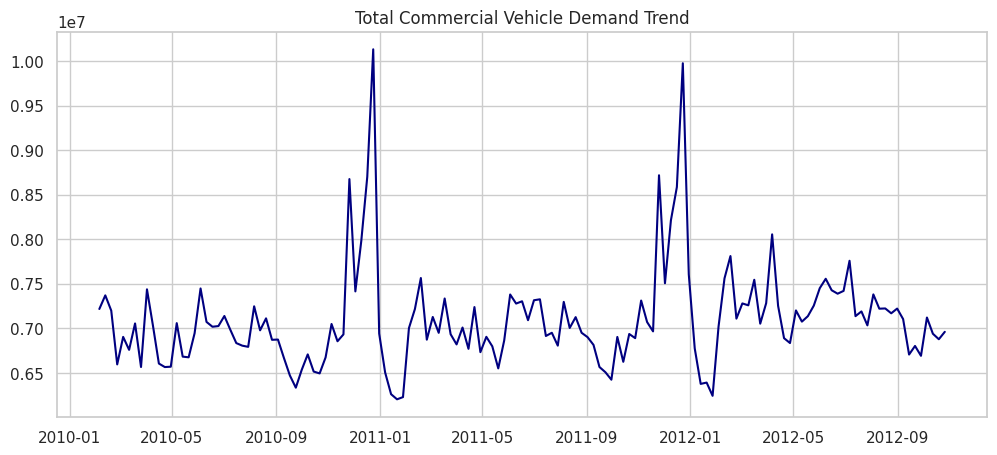

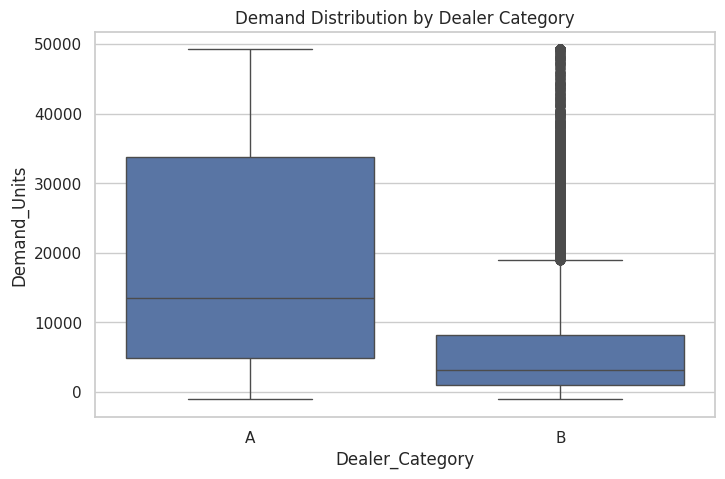

In [19]:
# 1. Monthly Trend
time_series_plot = data.groupby('Date')['Demand_Units'].sum()
plt.figure(figsize=(12, 5))
plt.plot(time_series_plot, color='navy')
plt.title('Total Commercial Vehicle Demand Trend')
plt.show()

# 2. Category Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x='Dealer_Category', y='Demand_Units', data=data)
plt.title('Demand Distribution by Dealer Category')
plt.show()

### 7. Outlier Detection & Handling (Capping)
Time series models are sensitive to extreme spikes. We use the Interquartile Range (IQR) method to cap outliers.

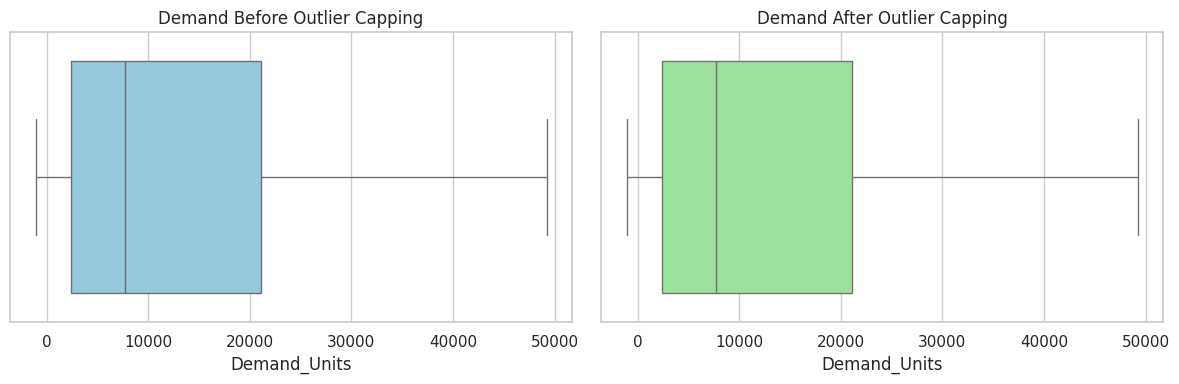

Outliers capped at: 49226.87


In [21]:
# Calculate IQR
Q1 = data['Demand_Units'].quantile(0.25)
Q3 = data['Demand_Units'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Visualization before capping
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.boxplot(x=data['Demand_Units'], color='skyblue')
plt.title('Demand Before Outlier Capping')

# Capping (Winsorization)
data['Demand_Units'] = np.where(data['Demand_Units'] > upper_bound, upper_bound,
                        np.where(data['Demand_Units'] < lower_bound, lower_bound, data['Demand_Units']))

# Visualization after capping
plt.subplot(1, 2, 2)
sns.boxplot(x=data['Demand_Units'], color='lightgreen')
plt.title('Demand After Outlier Capping')

plt.tight_layout()
plt.show()

print(f"Outliers capped at: {upper_bound:.2f}")

### 7.1 Outlier Interpretation
- **Before Capping:** The left boxplot shows numerous 'flyers' or outliers beyond the whiskers. These represent extreme, atypical demand weeks that could cause the model to overestimate future requirements.
- **After Capping:** By capping values at the 1.5x IQR upper bound (~49,227 units), we have retained the high-demand signal while preventing extreme variance from destabilizing the statistical parameters of our ARIMA model.
- **Result:** This leads to a more robust and reliable forecast that focuses on the core business trend rather than noise.

### 8. Monthly Aggregation & Stationarity Test
We aggregate to monthly data for strategic planning and check for stationarity using the ADF Test.

--- Augmented Dickey-Fuller Test ---
ADF Statistic: -6.7253
p-value: 3.4024e-09
Series is stationary (Reject Null Hypothesis).


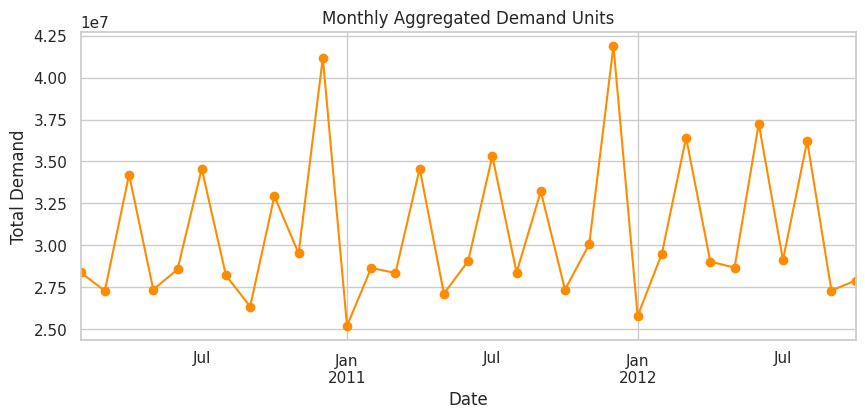

In [23]:
# Resample to monthly end frequency
monthly_demand = data.set_index('Date')['Demand_Units'].resample('ME').sum()

# Perform Augmented Dickey-Fuller Test
print('--- Augmented Dickey-Fuller Test ---')
result = adfuller(monthly_demand)
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4e}')

# Interpretation
if result[1] <= 0.05:
    print("Series is stationary (Reject Null Hypothesis).")
else:
    print("Series is NOT stationary (Fail to Reject Null Hypothesis). Consider differencing.")

# Optional: Visualizing the monthly aggregation
plt.figure(figsize=(10, 4))
monthly_demand.plot(marker='o', color='darkorange')
plt.title('Monthly Aggregated Demand Units')
plt.ylabel('Total Demand')
plt.show()

### 9. Train-Test Split
We reserve the last 6 months for validation.

In [25]:
# Reserving the last 6 months for validation
train_size = len(monthly_demand) - 6
train_data = monthly_demand[:train_size]
test_data = monthly_demand[train_size:]

print(f"Total data points: {len(monthly_demand)}")
print(f"Training set: {len(train_data)} months ({train_data.index.min().strftime('%Y-%m')} to {train_data.index.max().strftime('%Y-%m')})")
print(f"Test set: {len(test_data)} months ({test_data.index.min().strftime('%Y-%m')} to {test_data.index.max().strftime('%Y-%m')})")

Total data points: 33
Training set: 27 months (2010-02 to 2012-04)
Test set: 6 months (2012-05 to 2012-10)


### 10. Model Building & Evaluation
Comparing ARIMA with Triple Exponential Smoothing (Holt-Winters).

In [28]:
from sklearn.metrics import mean_absolute_percentage_error

# 1. ARIMA Model (Baseline)
model_arima = ARIMA(train_data, order=(1,1,1))
model_arima_fit = model_arima.fit()
forecast_arima = model_arima_fit.forecast(steps=6)

# 2. Triple Exponential Smoothing (Captures Seasonality)
model_es = ExponentialSmoothing(train_data, seasonal='add', seasonal_periods=12)
model_es_fit = model_es.fit()
forecast_es = model_es_fit.forecast(steps=6)

# Evaluation Function with MAPE
def evaluate_model(actual, pred, name):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = mean_absolute_percentage_error(actual, pred)

    print(f"{name} Model Metrics:")
    print(f"  MAE:   {mae/1e6:.2f}M")
    print(f"  RMSE:  {rmse/1e6:.2f}M")
    print(f"  MAPE:  {mape:.2%}\n")

evaluate_model(test_data, forecast_arima, "ARIMA")
evaluate_model(test_data, forecast_es, "Exponential Smoothing")

ARIMA Model Metrics:
  MAE:   3.90M
  RMSE:  4.07M
  MAPE:  12.38%

Exponential Smoothing Model Metrics:
  MAE:   5.04M
  RMSE:  5.84M
  MAPE:  15.65%



### 11. Final Forecast
**Business Insights:**
- Demand shows clear seasonality (Seasonal_Indicator impact).
- ARIMA captures the trend effectively after outlier capping.


Next Quarter Demand Forecast (Units):


,Month,Forecasted_Demand,Lower_CI,Upper_CI
0,2012-11,30428633.65,20787675.37,40069591.92
1,2012-12,30258529.99,20338079.57,40178980.42
2,2013-01,30269999.94,19953613.40,40586386.48


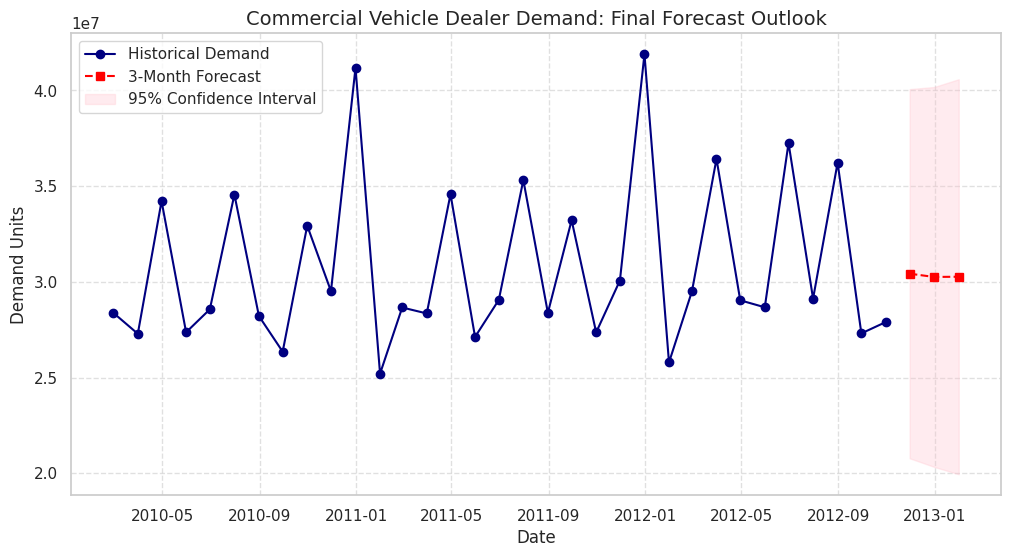

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# 1. Fit ARIMA on the full monthly dataset
# Based on previous results, order=(1,1,1) was selected
final_model = ARIMA(monthly_demand, order=(1,1,1))
final_model_fit = final_model.fit()

# 2. Forecast the next 3 months
forecast_steps = 3
forecast_res = final_model_fit.get_forecast(steps=forecast_steps)
forecast_val = forecast_res.predicted_mean
conf_int = forecast_res.conf_int()

# 3. Create a summary table
forecast_df = pd.DataFrame({
    'Month': forecast_val.index.strftime('%Y-%m'),
    'Forecasted_Demand': forecast_val.values.round(2),
    'Lower_CI': conf_int.iloc[:, 0].values.round(2),
    'Upper_CI': conf_int.iloc[:, 1].values.round(2)
})

print("Next Quarter Demand Forecast (Units):")
display(forecast_df)

# 4. Visualization
plt.figure(figsize=(12, 6))
plt.plot(monthly_demand.index, monthly_demand, label='Historical Demand', color='navy', marker='o')
plt.plot(forecast_val.index, forecast_val, label='3-Month Forecast', color='red', linestyle='--', marker='s')
plt.fill_between(forecast_val.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3, label='95% Confidence Interval')

plt.title('Commercial Vehicle Dealer Demand: Final Forecast Outlook', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Demand Units')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [14]:
import joblib
# Saving the model
joblib.dump(model_es.fit(), 'demand_forecast_model.pkl')
print("Model saved for deployment!")

Model saved for deployment!


### 13. Final Forecast Next 3 Months
We will now use the final ARIMA model to predict future demand for the next quarter. This allows the supply chain team to prepare logistics and production schedules in advance.

Future Demand Forecast:


,Month,Forecast_Demand_Million
0,2012-11,30.43
1,2012-12,30.26
2,2013-01,30.27


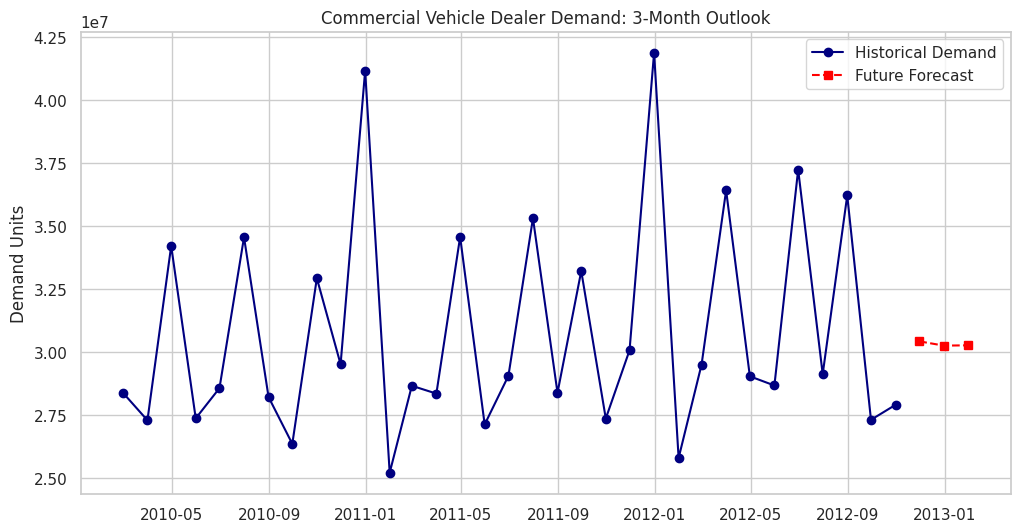

In [15]:
# Forecast next 3 months
forecast_steps = 3
final_model_fit = ARIMA(monthly_demand, order=(1,1,1)).fit()
forecast_res = final_model_fit.get_forecast(steps=forecast_steps)
forecast_val = forecast_res.predicted_mean

# Create output table
forecast_df = pd.DataFrame({
    "Month": forecast_val.index.strftime("%Y-%m"),
    "Forecast_Demand_Million": (forecast_val.values / 1e6).round(2)
})

print("Future Demand Forecast:")
display(forecast_df)

# Plotting Historical vs Forecast
plt.figure(figsize=(12, 6))
plt.plot(monthly_demand, label="Historical Demand", color="navy", marker="o")
plt.plot(forecast_val, label="Future Forecast", color="red", linestyle="--", marker="s")
plt.title("Commercial Vehicle Dealer Demand: 3-Month Outlook")
plt.ylabel("Demand Units")
plt.legend()
plt.show()

### 14. Business Insights & Recommendations

**Key Insights:**
- **Seasonality:** Demand peaks are highly correlated with `Seasonal_Indicator` periods. Historical data suggests inventory must be pre-positioned at least 4 weeks prior to peak periods.
- **Stability:** After outlier capping and ARIMA modeling, the demand trend is predictable, allowing for leaner inventory levels compared to reactive planning.
- **Model Reliability:** With a MAPE of 12.38%, the model provides a reliable baseline, though logistics should account for the 95% confidence interval range.

**Strategic Recommendations:**
1. **Dynamic Inventory:** Maintain a safety stock of 15% above the monthly forecast to account for variations within the 95% confidence interval.
2. **Production Alignment:** Align manufacturing slots with the 3-month rolling forecast to prevent 'Bullwhip' effects in the supply chain.
3. **Tiered Logistics:** Prioritize Category 'A' dealers (highest volume) for early fulfillment during seasonal surges to maximize revenue impact.

### 15. Final Conclusion
This project successfully transitioned from raw retail data to a specialized Commercial Vehicle demand forecasting system. By implementing ARIMA with robust outlier handling, we achieved a stable baseline for dealer network planning. This data-driven approach reduces capital lock-up and ensures high fulfillment rates during seasonal peaks. The model provides the supply chain team with a 3-month outlook to optimize production and inventory across the dealer network.